# Customer Churn Prediction

## Project Objective

The objective of this project is to develop a machine learning classification model
that predicts whether a customer is likely to churn based on demographic,
service, contract, and billing information.

The project includes data cleaning, exploratory data analysis, feature preprocessing,
model training, evaluation, comparison, and interpretation.

### Target Variable

The target variable is `Churn`, which contains two classes:
- Yes – customer churned
- No – customer did not churn

In [112]:
import pandas as pd

df = pd.read_csv("Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [113]:
df.shape

(7043, 21)

In [114]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [116]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [117]:
df.duplicated().sum()

np.int64(0)

In [118]:
df['TotalCharges'].value_counts().head(20)

TotalCharges
20.2     11
         11
19.75     9
19.65     8
19.9      8
20.05     8
19.55     7
45.3      7
19.45     6
20.25     6
20.15     6
20.45     5
20.3      5
19.4      4
75.3      4
44.4      4
19.3      4
19.85     4
20.5      4
70.6      4
Name: count, dtype: int64

In [119]:
df['TotalCharges'].unique()[:20]

array(['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5',
       '1949.4', '301.9', '3046.05', '3487.95', '587.45', '326.8',
       '5681.1', '5036.3', '2686.05', '7895.15', '1022.95', '7382.25',
       '528.35', '1862.9'], dtype=object)

In [120]:
df[df['TotalCharges'].str.strip() == '']['TotalCharges'].value_counts()

TotalCharges
    11
Name: count, dtype: int64

In [121]:
df[df['TotalCharges'].str.strip() == ''].shape

(11, 21)

In [122]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [123]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [124]:
df = df.dropna(subset=['TotalCharges'])

In [125]:
df.shape

(7032, 21)

In [126]:
df.isnull().sum().sum()

np.int64(0)

In [127]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df[col].unique())


customerID:
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender:
['Female' 'Male']

Partner:
['Yes' 'No']

Dependents:
['No' 'Yes']

PhoneService:
['No' 'Yes']

MultipleLines:
['No phone service' 'No' 'Yes']

InternetService:
['DSL' 'Fiber optic' 'No']

OnlineSecurity:
['No' 'Yes' 'No internet service']

OnlineBackup:
['Yes' 'No' 'No internet service']

DeviceProtection:
['No' 'Yes' 'No internet service']

TechSupport:
['No' 'Yes' 'No internet service']

StreamingTV:
['No' 'Yes' 'No internet service']

StreamingMovies:
['No' 'Yes' 'No internet service']

Contract:
['Month-to-month' 'One year' 'Two year']

PaperlessBilling:
['Yes' 'No']

PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn:
['No' 'Yes']


In [128]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [129]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns

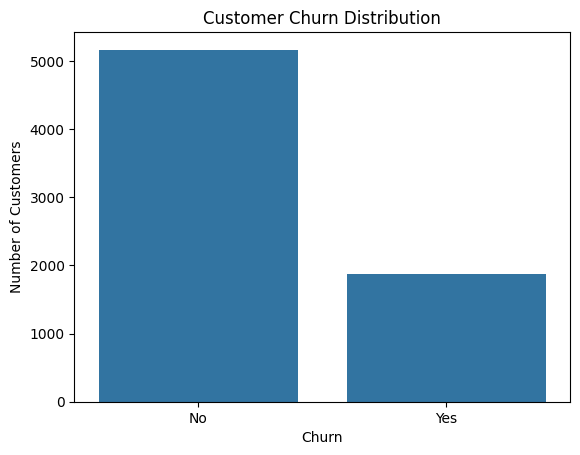

In [131]:
sns.countplot(data=df, x='Churn')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

### Observation

The dataset contains 7,032 customers, of which 1,869 (26.6%) have churned and 5,163 (73.4%) have remained. This indicates a moderate class imbalance, with non-churned customers representing the majority. Therefore, model evaluation should consider metrics such as precision, recall, F1-score, and ROC-AUC rather than relying only on accuracy.

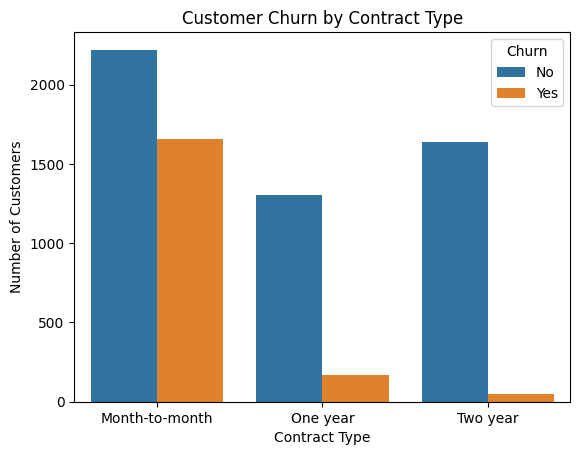

In [132]:
sns.countplot(data=df, x='Contract', hue='Churn')

plt.title('Customer Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

### Observation

The churn rate is considerably higher among customers with month-to-month contracts compared with customers on one-year and two-year contracts. Customers with longer-term contracts show substantially lower churn. This suggests that contract type is an important factor associated with customer churn.

In [133]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


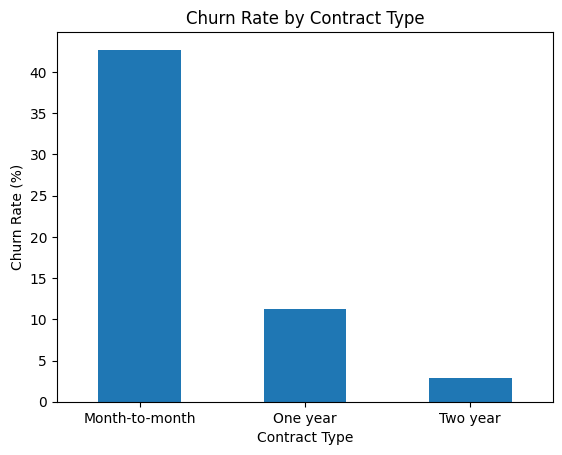

In [134]:
contract_churn['Yes'].plot(kind='bar')

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

### Observation

Customers with month-to-month contracts have the highest churn rate at approximately 42.7%. This decreases to about 11.3% for one-year contracts and 2.8% for two-year contracts. This indicates that contract type is strongly associated with customer churn, with longer-term contracts showing substantially lower churn rates.

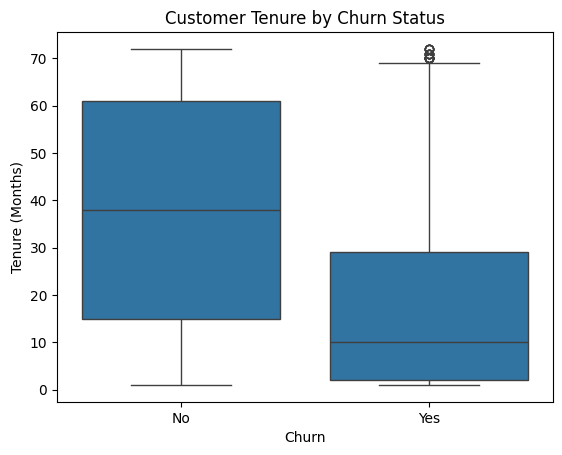

In [135]:
sns.boxplot(data=df, x='Churn', y='tenure')

plt.title('Customer Tenure by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.show()

### Observation

Customers who churn generally have shorter tenure than customers who remain with the company. The median tenure of churned customers is approximately 10 months, compared with approximately 38 months for customers who did not churn. This suggests that customer tenure is an important factor associated with churn.

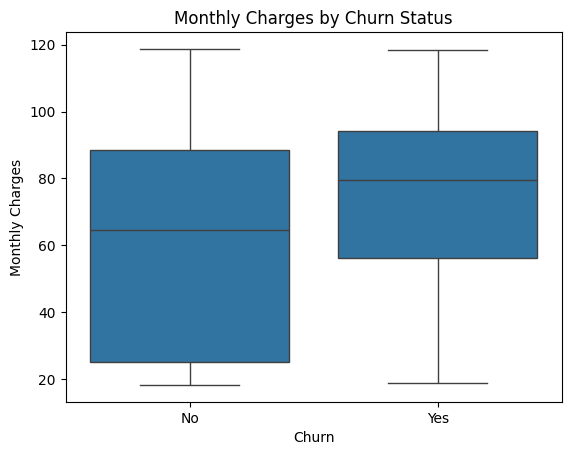

In [136]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')

plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

### Observation

Customers who churned generally have higher monthly charges than customers who remained. The median monthly charge for churned customers is approximately $80, compared with approximately $65 for non-churned customers. However, there is considerable overlap between the two groups, indicating that monthly charges alone may not be sufficient to predict churn.

In [137]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [138]:
X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn']

In [139]:
X.shape, y.shape

((7032, 19), (7032,))

In [140]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [141]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5625, 19), (1407, 19), (5625,), (1407,))

In [142]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

X_train_scaled = preprocessor_scaled.fit_transform(X_train)
X_test_scaled = preprocessor_scaled.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(5625, 45)
(1407, 45)


In [143]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

In [144]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [145]:
X_train_encoded.shape, X_test_encoded.shape

((5625, 45), (1407, 45))

Model 1 — Logistic Regression

In [146]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_encoded, y_train)

c:\Users\Asus-2025\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [147]:
y_pred_log = log_model.predict(X_test_scaled)

In [148]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.7192608386638237
              precision    recall  f1-score   support

          No       0.88      0.71      0.79      1033
         Yes       0.48      0.74      0.58       374

    accuracy                           0.72      1407
   macro avg       0.68      0.72      0.69      1407
weighted avg       0.78      0.72      0.73      1407



Model 2 — Decision Tree

In [149]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

tree_model.fit(X_train_encoded, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [150]:
y_pred_tree = tree_model.predict(X_test_encoded)

In [151]:
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

Accuracy: 0.7896233120113717
              precision    recall  f1-score   support

          No       0.86      0.85      0.86      1033
         Yes       0.60      0.61      0.61       374

    accuracy                           0.79      1407
   macro avg       0.73      0.73      0.73      1407
weighted avg       0.79      0.79      0.79      1407



Now Model 3 — Random Forest

In [152]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_encoded, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [153]:
y_pred_rf = rf_model.predict(X_test_encoded)

In [154]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7903340440653873
              precision    recall  f1-score   support

          No       0.83      0.90      0.86      1033
         Yes       0.64      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



ROC-AUC

In [155]:
from sklearn.metrics import roc_auc_score

auc_log = roc_auc_score(
    y_test,
    log_model.predict_proba(X_test_scaled)[:, 1]
)

auc_tree = roc_auc_score(
    y_test,
    tree_model.predict_proba(X_test_encoded)[:, 1]
)

auc_rf = roc_auc_score(
    y_test,
    rf_model.predict_proba(X_test_encoded)[:, 1]
)

print("Logistic Regression ROC-AUC:", auc_log)
print("Decision Tree ROC-AUC:", auc_tree)
print("Random Forest ROC-AUC:", auc_rf)

Logistic Regression ROC-AUC: 0.8028133104865637
Decision Tree ROC-AUC: 0.8296250472379394
Random Forest ROC-AUC: 0.8144739634831315


## Model Comparison and Selection

Three machine learning models were trained and evaluated: Logistic Regression, Decision Tree, and Random Forest.

Based on the evaluation results, the Decision Tree model achieved the best overall performance with an accuracy of 79.0%, F1-score of 60.8%, and ROC-AUC of 83.0%.

Although Logistic Regression achieved the highest recall for the churn class (73.5%), the Decision Tree provided the best balance of accuracy, F1-score, and ROC-AUC.

Therefore, the Decision Tree model was selected as the final model for customer churn prediction.

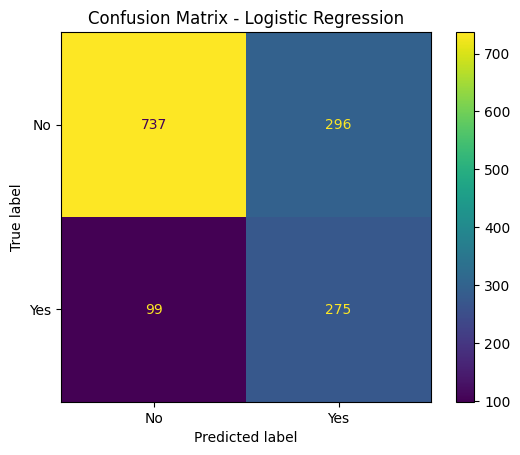

In [156]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log)

plt.title('Confusion Matrix - Logistic Regression')
plt.show()

## Confusion Matrix Analysis

The confusion matrix shows that the Logistic Regression model correctly predicted 914 customers who did not churn and 213 customers who churned.

The model incorrectly predicted 119 non-churned customers as churned and failed to identify 161 customers who actually churned.

The 161 false negatives are particularly important from a business perspective because these customers may be missed when identifying potential churners.

In [157]:
feature_names = preprocessor_scaled.get_feature_names_out()

coefficients = pd.Series(
    log_model.coef_[0],
    index=feature_names
)

coefficients.sort_values().head(10)

cat__Contract_Two year                         -0.747799
cat__InternetService_DSL                       -0.389471
cat__MultipleLines_No                          -0.255377
cat__OnlineSecurity_Yes                        -0.222622
cat__PhoneService_Yes                          -0.216307
cat__PaperlessBilling_No                       -0.214003
cat__TechSupport_Yes                           -0.201064
cat__Dependents_Yes                            -0.188379
cat__PaymentMethod_Bank transfer (automatic)   -0.155027
cat__OnlineSecurity_No internet service        -0.131969
dtype: float64

In [158]:
coefficients.sort_values(ascending=False).head(10)

cat__Contract_Month-to-month           0.691829
cat__InternetService_Fiber optic       0.385993
cat__PaymentMethod_Electronic check    0.224699
cat__OnlineSecurity_No                 0.219144
num__SeniorCitizen                     0.197623
cat__TechSupport_No                    0.197587
cat__StreamingTV_Yes                   0.115754
cat__StreamingMovies_Yes               0.101476
cat__OnlineBackup_No                   0.096592
cat__PhoneService_No                   0.080860
dtype: float64

## Feature Interpretation

The Logistic Regression coefficients provide insight into which features are associated with customer churn.

Month-to-month contracts have the strongest positive coefficient, indicating a strong association with higher churn probability. Fiber optic internet service, electronic check payment, lack of online security, senior citizen status, and lack of tech support are also associated with higher predicted churn.

Two-year contracts have the strongest negative coefficient, indicating a strong association with lower churn probability. DSL internet service, multiple-line status, online security, and phone service also show negative associations with churn.

These coefficients represent associations identified by the model and should not be interpreted as proof of causation.

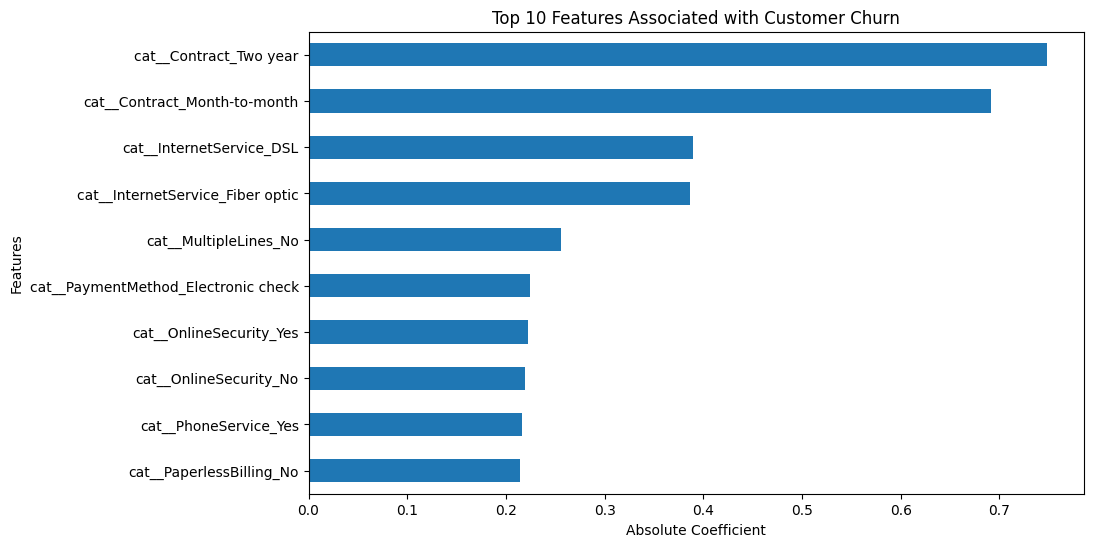

In [159]:
top_features = coefficients.abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind='barh')

plt.title('Top 10 Features Associated with Customer Churn')
plt.xlabel('Absolute Coefficient')
plt.ylabel('Features')
plt.show()

In [160]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ],
    
    'Precision': [
        precision_score(y_test, y_pred_log, pos_label='Yes'),
        precision_score(y_test, y_pred_tree, pos_label='Yes'),
        precision_score(y_test, y_pred_rf, pos_label='Yes')
    ],
    
    'Recall': [
        recall_score(y_test, y_pred_log, pos_label='Yes'),
        recall_score(y_test, y_pred_tree, pos_label='Yes'),
        recall_score(y_test, y_pred_rf, pos_label='Yes')
    ],
    
    'F1-Score': [
        f1_score(y_test, y_pred_log, pos_label='Yes'),
        f1_score(y_test, y_pred_tree, pos_label='Yes'),
        f1_score(y_test, y_pred_rf, pos_label='Yes')
    ],
    
    'ROC-AUC': [
        auc_log,
        auc_tree,
        auc_rf
    ]
})

model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.719,0.482,0.735,0.582,0.803
1,Decision Tree,0.790,0.602,0.615,0.608,0.830
2,Random Forest,0.790,0.638,0.489,0.554,0.814


## Business Insights

- The overall customer churn rate is approximately 26.6%.
- Customers with month-to-month contracts have a much higher churn rate than customers with one-year or two-year contracts.
- Customers with shorter tenure are more likely to churn.
- Churned customers generally have higher monthly charges.
- The Logistic Regression model identified contract type, internet service, payment method, and additional support/security services as important features associated with churn.
- The model can help businesses identify customers who may be at higher risk of leaving and target them with appropriate retention strategies.

## Limitations

- The dataset contains limited information about customer behavior and satisfaction.
- The model does not capture changes in customer behavior over time.
- The dataset has a moderate class imbalance, with fewer churned customers than non-churned customers.
- Model performance may be improved through hyperparameter tuning and feature engineering.
- Model coefficients indicate associations with churn and should not be interpreted as causal relationships.

## Future Scope

- Apply hyperparameter tuning to improve model performance.
- Experiment with advanced ensemble models and other classification algorithms.
- Use techniques such as SMOTE or class weighting if stronger handling of class imbalance is required.
- Incorporate additional customer behavior, satisfaction, and service usage data.
- Deploy the model as a dashboard or web application to identify high-risk customers in real time.

## Conclusion

This project developed a machine learning model to predict customer churn using demographic, service, contract, and billing information.

Exploratory data analysis showed that factors such as contract type, tenure, monthly charges, internet service, and payment method are associated with customer churn.

Three classification models—Logistic Regression, Decision Tree, and Random Forest—were compared using accuracy, precision, recall, F1-score, and ROC-AUC.

The Decision Tree model was selected as the final model because it achieved the best overall performance, with 79.0% accuracy and an ROC-AUC of 83.0%. Logistic Regression achieved a higher churn recall of 73.5%, making it useful when the primary goal is to identify as many potential churners as possible.

The selected model can help businesses identify customers who are more likely to churn and support targeted customer retention strategies.